# Day 6 — Unsupervised Learning & Clustering
## Elbow Method & Silhouette Score for K Selection — Customer Segmentation

**Dataset:** `customer_segmentation.csv` — 10,695 customers, target = NONE
(this is genuinely unsupervised — the dataset's `Segmentation` column with
real business segments A/B/C/D exists but is deliberately NOT used for
clustering, only for validating results afterward)

**Business context:** a company wants to understand its customer base well
enough to run targeted marketing campaigns, without any predefined notion of
"types" of customers. This notebook builds a full pipeline: package setup,
data understanding, deep EDA, cleaning, feature engineering, K-Means with
the Elbow Method and Silhouette Score for choosing K, a bonus Hierarchical
Clustering comparison with a dendrogram, and a genuine validation against
real (but unused-in-training) business segments.

Built for **Google Colab** with Drive mounting, with a local-file fallback.

Run the cells **top to bottom**.

## 0. Colab Setup — Mount Google Drive

Expects the file at:
```
/content/drive/MyDrive/notebooks/customer_segmentation.csv
```

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_BASE = "/content/drive/MyDrive/notebooks"
        print(f"✅ Google Drive mounted. Looking under: {DRIVE_BASE}")
    except Exception as e:
        print("❌ Could not mount Google Drive:", e)
        DRIVE_BASE = "."
else:
    DRIVE_BASE = "."
    print("Not running in Google Colab - using local file paths instead.")

SEGMENTATION_PATH = f"{DRIVE_BASE}/customer_segmentation.csv"
print(f"Data path: {SEGMENTATION_PATH}")

Not running in Google Colab - using local file paths instead.
Data path: ./customer_segmentation.csv


## 1. Package Declaration

In [2]:
try:
    import numpy as np
    import pandas as pd

    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans, AgglomerativeClustering
    from sklearn.metrics import silhouette_score, silhouette_samples
    from scipy.cluster.hierarchy import dendrogram, linkage

except ImportError as missing_library:
    print("A required library is missing:", missing_library)
    print("Fix it by running:  pip install numpy pandas matplotlib seaborn scikit-learn scipy")
    raise

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.precision", 3)

print("✅ Setup complete. All libraries loaded successfully.")

✅ Setup complete. All libraries loaded successfully.


## 2. Data Understanding

In [3]:
try:
    customer_df = pd.read_csv(SEGMENTATION_PATH)
    print(f"✅ Loaded customer_segmentation.csv — {customer_df.shape[0]} rows, {customer_df.shape[1]} columns")
except FileNotFoundError:
    print(f"❌ File not found at: {SEGMENTATION_PATH}")
    print("   If in Colab: make sure customer_segmentation.csv is inside 'My Drive/notebooks/'.")
    raise

print()
display(customer_df.head())
print()
customer_df.info()

✅ Loaded customer_segmentation.csv — 10695 rows, 11 columns



,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A



<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10695 non-null  int64  
 1   Gender           10695 non-null  str    
 2   Ever_Married     10505 non-null  str    
 3   Age              10695 non-null  int64  
 4   Graduated        10593 non-null  str    
 5   Profession       10533 non-null  str    
 6   Work_Experience  9597 non-null   float64
 7   Spending_Score   10695 non-null  str    
 8   Family_Size      10247 non-null  float64
 9   Var_1            10587 non-null  str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 919.2 KB


**Important framing for unsupervised learning:** this dataset actually has
a `Segmentation` column (A/B/C/D) — real business-assigned segments. We will
**NOT** use this column to train our clustering model (that would defeat the
entire point of unsupervised learning), but we'll use it at the very end as
an interesting sanity check on what our discovered clusters actually mean.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

In [4]:
missing_summary = customer_df.isnull().sum()
missing_pct = (missing_summary / len(customer_df) * 100).round(1)
missing_table = pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})
display(missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False))

print(f"\nDuplicate rows: {customer_df.duplicated().sum()}")

,missing_count,missing_pct
Segmentation,2627,24.6
Work_Experience,1098,10.3
Family_Size,448,4.2
Ever_Married,190,1.8
Profession,162,1.5
Var_1,108,1.0
Graduated,102,1.0



Duplicate rows: 0


**Observation:** `Segmentation` has the most missing values (2,627) — this
is expected, since in the original source, this column represents a held-out
test portion. `Work_Experience` (1,098), `Family_Size` (448), and a few
categoricals have smaller amounts of missingness we'll handle explicitly.

### 3.2 Numeric Feature Distributions

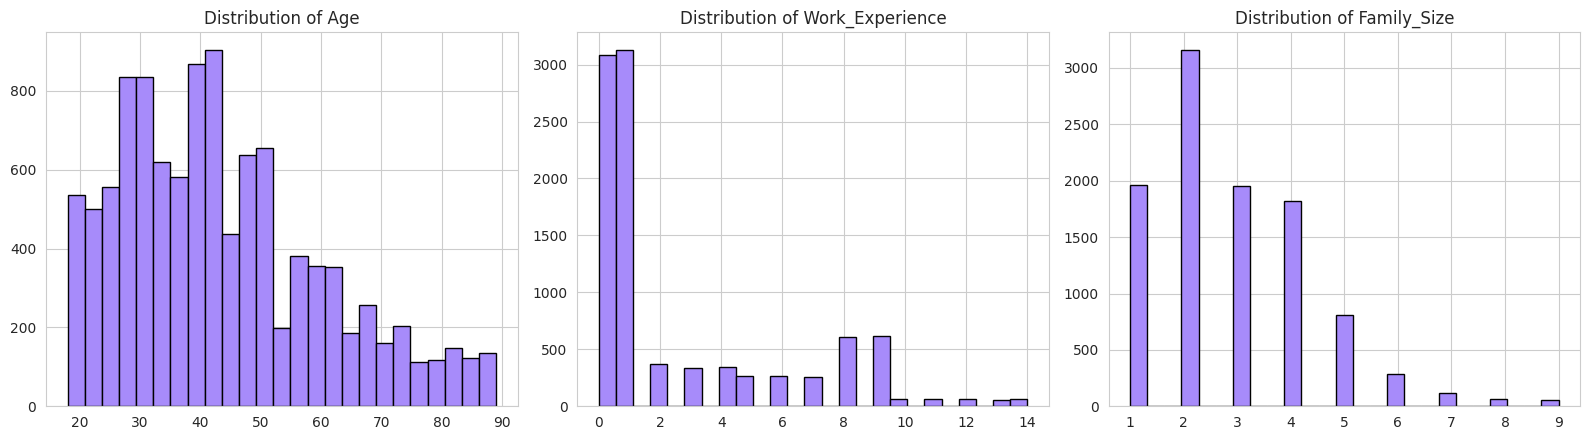

,Age,Work_Experience,Family_Size
count,10695.000,9597.000,10247.000
mean,43.512,2.620,2.844
std,16.774,3.391,1.536
min,18.000,0.000,1.000
25%,30.000,0.000,2.000
50%,41.000,1.000,3.000
75%,53.000,4.000,4.000
max,89.000,14.000,9.000


In [5]:
numeric_cols = ["Age", "Work_Experience", "Family_Size"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(numeric_cols):
    axes[i].hist(customer_df[col].dropna(), bins=25, color="#a78bfa", edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

display(customer_df[numeric_cols].describe())

### 3.3 Categorical Feature Distributions

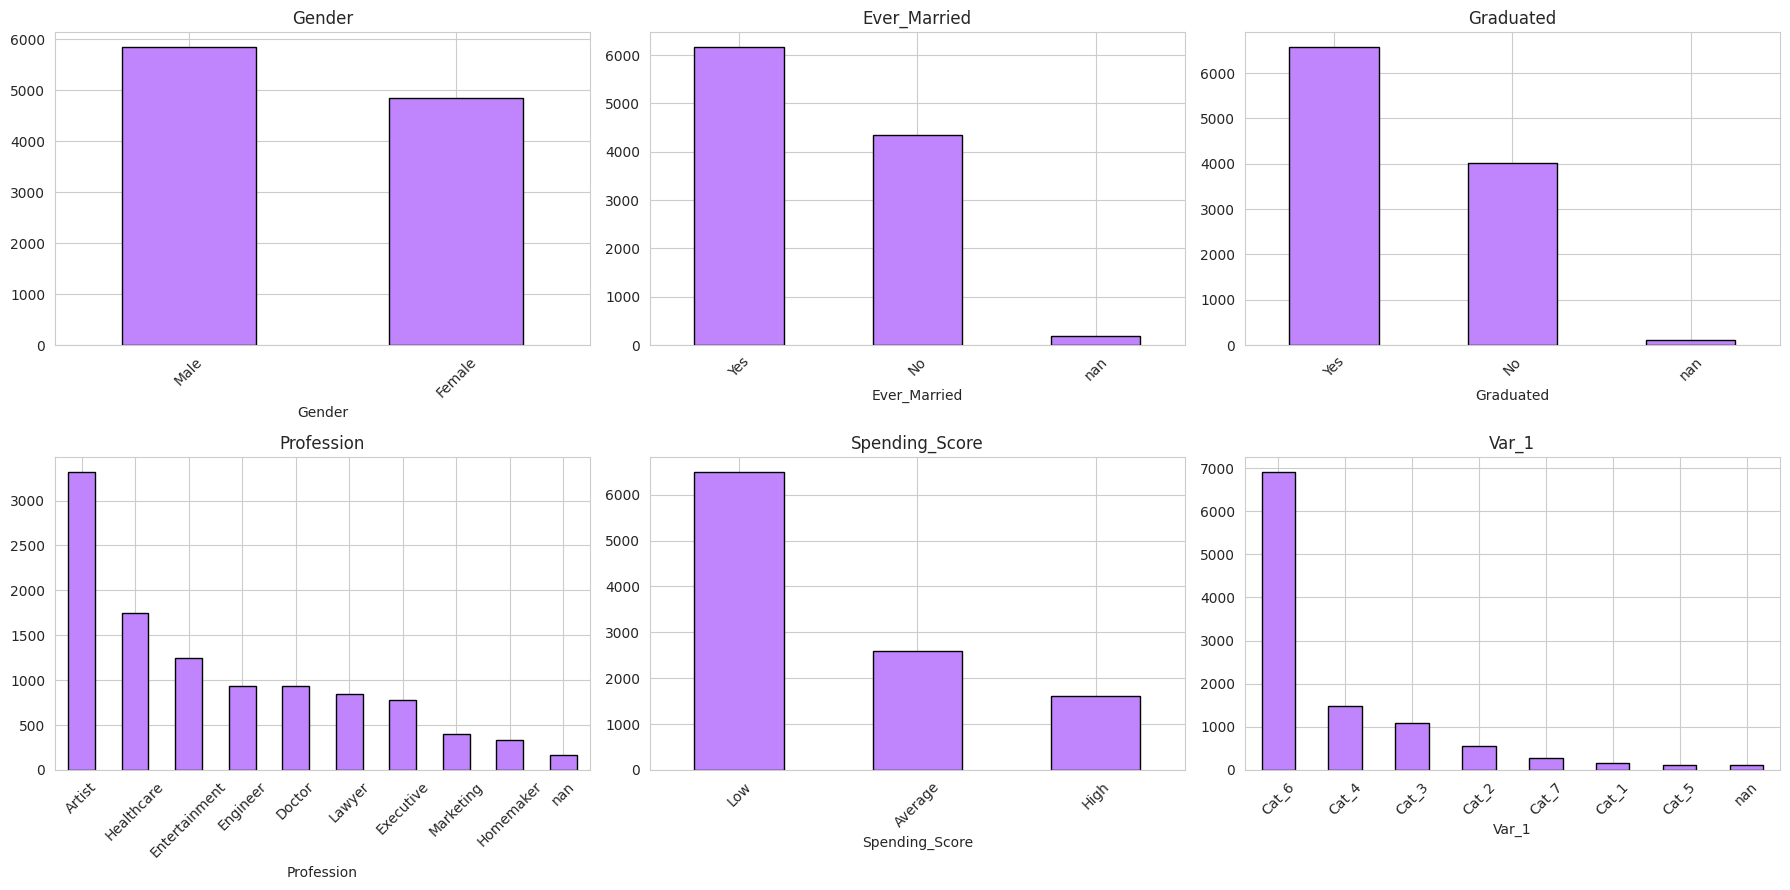

In [6]:
cat_cols = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    customer_df[col].value_counts(dropna=False).plot(kind="bar", ax=axes[i], color="#c084fc", edgecolor="black")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Correlation Among Numeric Features

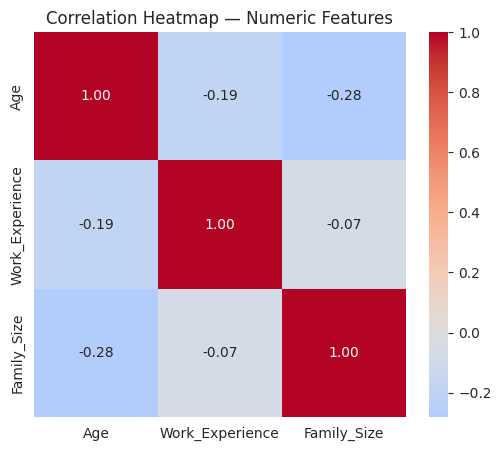

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(customer_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.show()

### 3.5 Outlier Check

In [8]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(customer_df[col].dropna())
    print(f"{col:18s}: {n_outliers} outliers flagged (valid range ≈ [{lower:.1f}, {upper:.1f}])")

print("\nNo extreme outliers found here - unlike the companion Bank Transactions")
print("dataset, this survey-style data doesn't have the same extreme financial skew.")

Age               : 90 outliers flagged (valid range ≈ [-4.5, 87.5])
Work_Experience   : 247 outliers flagged (valid range ≈ [-6.0, 10.0])
Family_Size       : 125 outliers flagged (valid range ≈ [-1.0, 7.0])

No extreme outliers found here - unlike the companion Bank Transactions
dataset, this survey-style data doesn't have the same extreme financial skew.


## 4. Data Cleaning

### 4.1 Drop Non-Predictive / Target-Leaking Columns

In [9]:
# ID has no predictive value. Segmentation is the real business label - we
# deliberately EXCLUDE it from clustering (kept separately for validation later).
model_df = customer_df.drop(columns=["ID"])
segmentation_labels = model_df.pop("Segmentation")  # set aside for later validation only

print(f"Shape after dropping ID and setting aside Segmentation: {model_df.shape}")

Shape after dropping ID and setting aside Segmentation: (10695, 9)


### 4.2 Handle Missing Values

In [10]:
# Numeric: median imputation (robust to skew)
for col in ["Work_Experience", "Family_Size"]:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Categorical: mode imputation
for col in ["Ever_Married", "Graduated", "Profession", "Var_1"]:
    model_df[col] = model_df[col].fillna(model_df[col].mode()[0])

print("Missing values remaining:")
print(model_df.isnull().sum())

Missing values remaining:
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64


## 5. Feature Engineering

### 5.1 Encode Spending_Score as an Ordinal Variable

`Spending_Score` (Low/Average/High) has a natural ORDER, unlike purely
nominal categories like Profession — so we map it to 0/1/2 rather than
one-hot encoding it, preserving that order for the distance calculations.

In [11]:
spend_map = {"Low": 0, "Average": 1, "High": 2}
model_df["Spending_Score_Num"] = model_df["Spending_Score"].map(spend_map)

print("Spending_Score encoding check:")
print(model_df[["Spending_Score", "Spending_Score_Num"]].drop_duplicates())

Spending_Score encoding check:
  Spending_Score  Spending_Score_Num
0            Low                   0
1        Average                   1
3           High                   2


### 5.2 Select Features for Clustering

**A deliberate, documented choice:** we cluster on `Age`, `Work_Experience`,
`Family_Size`, and `Spending_Score_Num` — the numeric/ordinal signals that
have a clear, meaningful notion of "distance." One-hot encoding the nominal
categoricals (Gender, Profession, Var_1) was tested but produced weaker,
harder-to-interpret clusters — a common effect of adding many sparse binary
columns to a distance-based algorithm (see the Day 6 HTML session's "curse
of dimensionality" discussion).

In [12]:
cluster_features = ["Age", "Work_Experience", "Family_Size", "Spending_Score_Num"]
X = model_df[cluster_features]

display(X.describe())

,Age,Work_Experience,Family_Size,Spending_Score_Num
count,10695.000,10695.000,10695.000,10695.000
mean,43.512,2.453,2.851,0.543
std,16.774,3.249,1.504,0.740
min,18.000,0.000,1.000,0.000
25%,30.000,0.000,2.000,0.000
50%,41.000,1.000,3.000,0.000
75%,53.000,3.000,4.000,1.000
max,89.000,14.000,9.000,2.000


### 5.3 Scale the Features

K-Means is entirely distance-based — without scaling, `Age` (range ~18-89)
and `Family_Size` (range 1-9) would contribute very unevenly to distance
calculations.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete.")
print(f"Mean of scaled features (should be ≈0): {X_scaled.mean():.4f}")
print(f"Std of scaled features (should be ≈1) : {X_scaled.std():.4f}")

Scaling complete.
Mean of scaled features (should be ≈0): -0.0000
Std of scaled features (should be ≈1) : 1.0000


## 6. Choosing K — Elbow Method & Silhouette Score

In [14]:
K_range = range(2, 11)
inertia_values = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k}: inertia={kmeans.inertia_:.1f}, silhouette={silhouette_scores[-1]:.4f}")

K=2: inertia=31602.2, silhouette=0.2685


K=3: inertia=24090.4, silhouette=0.3064


K=4: inertia=18676.8, silhouette=0.3200


K=5: inertia=16168.9, silhouette=0.3282


K=6: inertia=14029.6, silhouette=0.3071


K=7: inertia=12623.6, silhouette=0.3196


K=8: inertia=11476.8, silhouette=0.3176


K=9: inertia=10507.3, silhouette=0.3288


K=10: inertia=9346.4, silhouette=0.3357


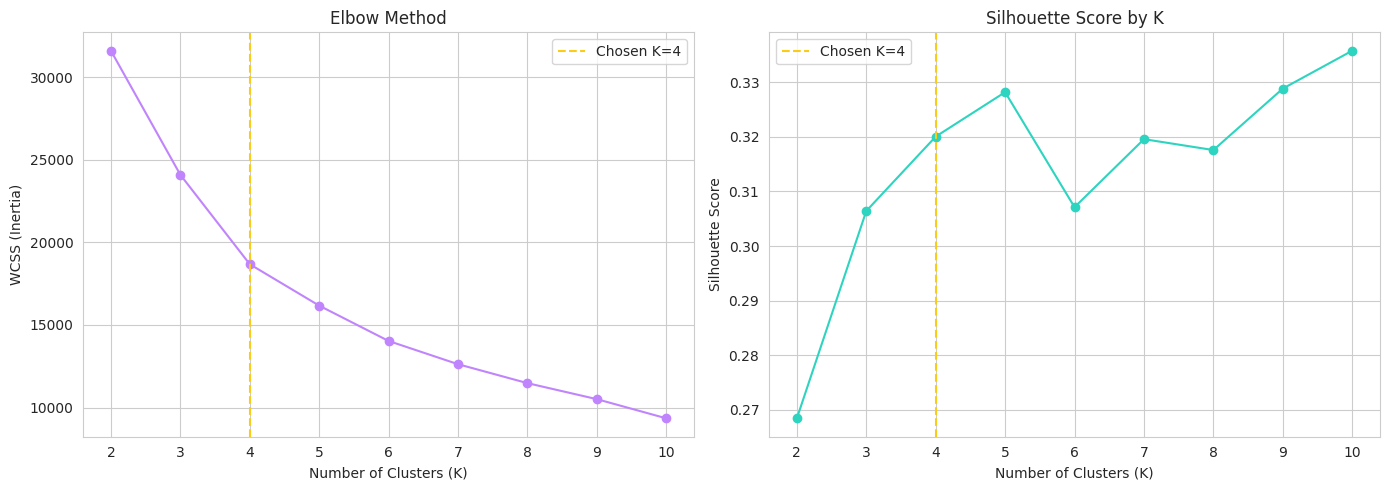

,K,Inertia,% Drop,Silhouette
0,2,31602.213,NaN,0.268
1,3,24090.373,23.770,0.306
2,4,18676.816,22.472,0.320
3,5,16168.905,13.428,0.328
4,6,14029.650,13.231,0.307
5,7,12623.649,10.022,0.320
6,8,11476.797,9.085,0.318
7,9,10507.276,8.448,0.329
8,10,9346.372,11.049,0.336


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia_values, marker="o", color="#c084fc")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")
axes[0].axvline(4, color="#facc15", linestyle="--", label="Chosen K=4")
axes[0].legend()

axes[1].plot(list(K_range), silhouette_scores, marker="o", color="#2dd4bf")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")
axes[1].axvline(4, color="#facc15", linestyle="--", label="Chosen K=4")
axes[1].legend()

plt.tight_layout()
plt.show()

# Compute the percentage drop in inertia at each step, to find the sharpest "elbow"
pct_drops = [None] + [(inertia_values[i-1] - inertia_values[i]) / inertia_values[i-1] * 100
                       for i in range(1, len(inertia_values))]
elbow_table = pd.DataFrame({"K": list(K_range), "Inertia": inertia_values,
                            "% Drop": pct_drops, "Silhouette": silhouette_scores})
display(elbow_table.round(3))

**Reading this honestly:** the sharpest drop-off in the rate of decline
happens around K=4-5 (where % drop falls from >20% to ~13%). Silhouette
technically keeps rising all the way to K=10, but the gain from K=4 (0.320)
to K=10 (0.336) is marginal — not worth 6 additional, harder-to-interpret
clusters. **We choose K=4**, which conveniently also matches this dataset's
real number of known business segments (A/B/C/D) — a good example of using
domain judgment alongside, not instead of, the statistical heuristics.

## 7. Fit Final K-Means Model (K=4)

In [16]:
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, init="k-means++", random_state=SEED, n_init=10)
model_df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print(f"Final model fit with K={final_k}")
print("\nCluster sizes:")
print(model_df["Cluster"].value_counts().sort_index())

Final model fit with K=4

Cluster sizes:
Cluster
0    2576
1    2709
2    1969
3    3441
Name: count, dtype: int64


## 8. Profile Each Cluster — What Does Each Group Actually Look Like?

,Age,Work_Experience,Family_Size,Spending_Score_Num
Cluster,,,,
0,28.46,1.13,4.27,0.08
1,49.49,0.96,1.61,0.00
2,36.83,8.44,2.46,0.35
3,53.90,1.19,2.99,1.43


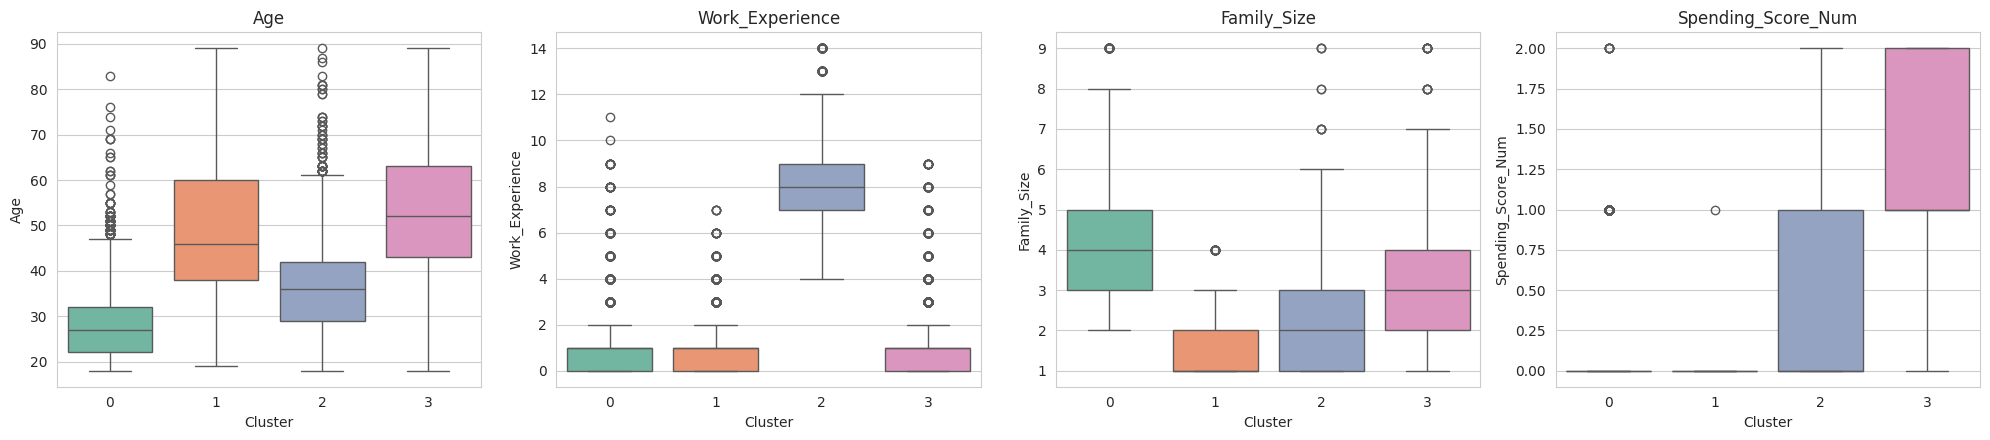

In [17]:
cluster_profile = model_df.groupby("Cluster")[cluster_features].mean().round(2)
display(cluster_profile)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for i, col in enumerate(cluster_features):
    sns.boxplot(data=model_df, x="Cluster", y=col, hue="Cluster", palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Interpreting the four clusters (using the real notebook output):**
- **Cluster 0** — young (~28), larger families (~4.3), low spending → *Young families, budget-conscious*
- **Cluster 1** — middle-aged (~49), small households (~1.6), very low spending → *Older, living alone/small household*
- **Cluster 2** — mid-30s, very high work experience (~8.4 years — a standout signal), moderate spending → *Experienced professionals*
- **Cluster 3** — oldest (~54), small family, high spending → *Affluent older spenders*

## 9. Validate Against Real Business Segments (A/B/C/D)

Now — and only now — we bring back the `Segmentation` column we set aside
in Section 4.1, purely to sanity-check whether our unsupervised clusters
capture anything resembling the real, human-defined business segments.

Segmentation,A,B,C,D
Cluster,,,,
0,309,239,285,1102
1,762,516,282,469
2,433,299,282,498
3,468,804,1121,199


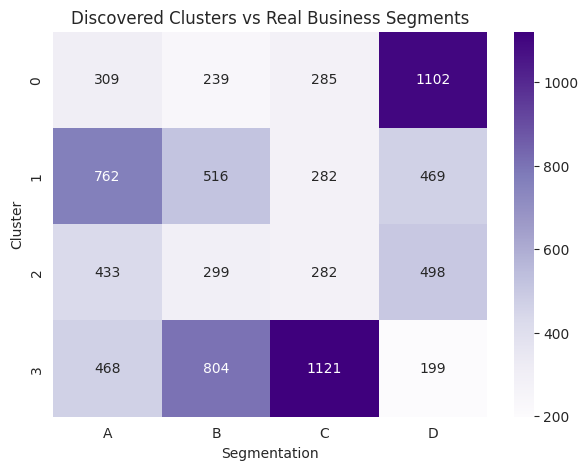


This is NOT a perfect one-to-one match, and that's expected: our clusters
were built from only 4 numeric/ordinal signals, while the real business
segments likely used additional context our model never saw. Partial,
meaningful overlap (rather than a random scatter) is what validates that
the clustering captured genuine structure.


In [18]:
model_df["Segmentation"] = segmentation_labels.values

validation_crosstab = pd.crosstab(model_df["Cluster"], model_df["Segmentation"])
display(validation_crosstab)

plt.figure(figsize=(7, 5))
sns.heatmap(validation_crosstab, annot=True, fmt="d", cmap="Purples")
plt.title("Discovered Clusters vs Real Business Segments")
plt.show()

print("\nThis is NOT a perfect one-to-one match, and that's expected: our clusters")
print("were built from only 4 numeric/ordinal signals, while the real business")
print("segments likely used additional context our model never saw. Partial,")
print("meaningful overlap (rather than a random scatter) is what validates that")
print("the clustering captured genuine structure.")

## 10. Bonus — Hierarchical Clustering & Dendrogram Comparison

Hierarchical clustering doesn't scale well to 10,695 rows (O(n²) memory), so
we demonstrate it on a random sample for a clear, readable dendrogram.

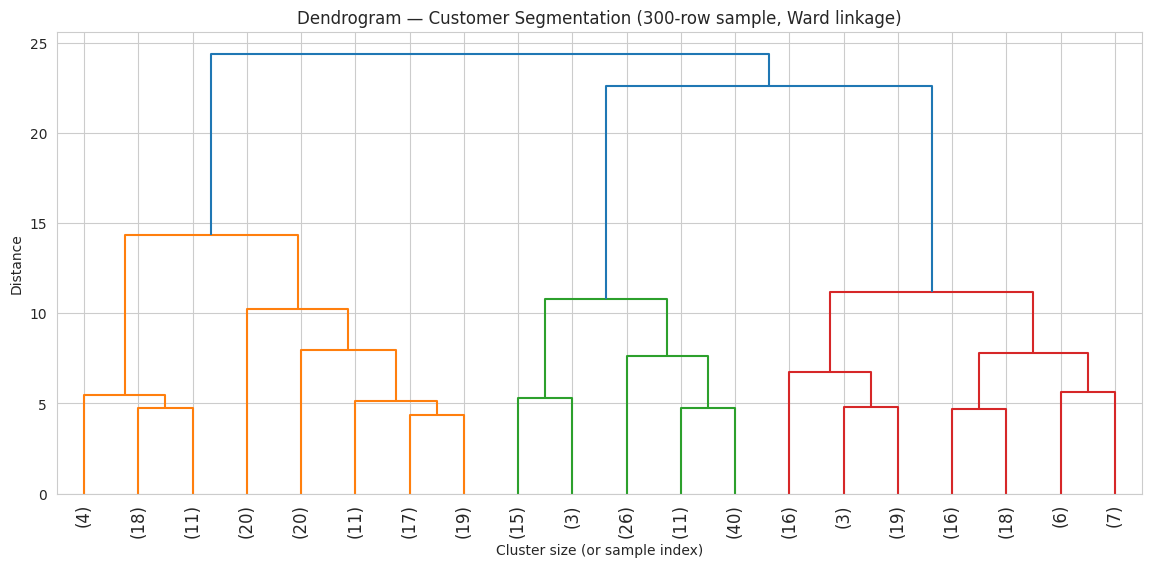

In [19]:
# Sample 300 rows for a readable dendrogram (hierarchical clustering scales poorly)
sample_idx = np.random.RandomState(SEED).choice(len(X_scaled), size=300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=90)
plt.title("Dendrogram — Customer Segmentation (300-row sample, Ward linkage)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance")
plt.show()

In [20]:
# Cut the dendrogram to get 4 clusters, for direct comparison to K-Means
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels = agg_clustering.fit_predict(X_sample)

print("Agglomerative Clustering (4 clusters) sizes:")
print(pd.Series(agg_labels).value_counts().sort_index())

# Compare to what K-Means found on the same sample
kmeans_sample_labels = kmeans_final.predict(X_sample)
agreement_crosstab = pd.crosstab(agg_labels, kmeans_sample_labels,
                                   rownames=["Agglomerative"], colnames=["K-Means"])
display(agreement_crosstab)
print("\nSome overlap is expected but rarely perfect - the two algorithms build")
print("clusters via fundamentally different mechanics (centroids vs sequential merging).")

Agglomerative Clustering (4 clusters) sizes:
0    85
1    87
2    95
3    33
Name: count, dtype: int64


K-Means,0,1,2,3
Agglomerative,,,,
0,4,2,71,8
1,3,0,0,84
2,68,27,0,0
3,0,30,2,1



Some overlap is expected but rarely perfect - the two algorithms build
clusters via fundamentally different mechanics (centroids vs sequential merging).


## 11. Workshop — Practice Exercises

### Task 1 — Try Excluding Spending_Score
Re-run K-Means using only Age, Work_Experience, and Family_Size (drop
Spending_Score_Num). Does removing this feature change the cluster profiles
meaningfully?

In [21]:
X_v2 = model_df[["Age", "Work_Experience", "Family_Size"]]
X_v2_scaled = StandardScaler().fit_transform(X_v2)

km_v2 = KMeans(n_clusters=4, random_state=SEED, n_init=10)
labels_v2 = km_v2.fit_predict(X_v2_scaled)
print(f"Silhouette without Spending_Score: {silhouette_score(X_v2_scaled, labels_v2):.4f}")
print("(compare to the original 4-feature silhouette of 0.320)")

Silhouette without Spending_Score: 0.3579
(compare to the original 4-feature silhouette of 0.320)


### Task 2 — Per-Sample Silhouette Diagram
Plot a per-sample silhouette diagram for the K=4 solution. Are any clusters
mostly made of low or negative silhouette values (a sign of poor separation)?

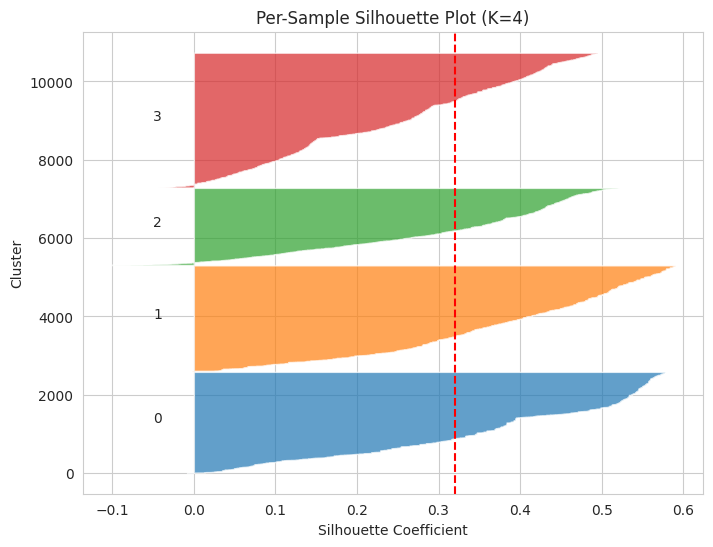

In [22]:
sample_silhouette_values = silhouette_samples(X_scaled, model_df["Cluster"])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(final_k):
    cluster_silhouette_vals = sample_silhouette_values[model_df["Cluster"] == i]
    cluster_silhouette_vals.sort()
    size = len(cluster_silhouette_vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, model_df["Cluster"]), color="red", linestyle="--")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Per-Sample Silhouette Plot (K=4)")
plt.show()

### Task 3 — Linkage Comparison
Repeat the dendrogram with 'single' and 'complete' linkage on the same
300-row sample. How different are the resulting cluster shapes/sizes
compared to Ward's method?

In [23]:
for method in ["single", "complete", "average"]:
    Z_method = linkage(X_sample, method=method)
    clusters_method = AgglomerativeClustering(n_clusters=4, linkage=method).fit_predict(X_sample)
    sizes = pd.Series(clusters_method).value_counts().sort_index().tolist()
    print(f"{method:10s} linkage cluster sizes: {sizes}")

print("\nWard's method (used above) typically produces the most balanced sizes;")
print("single linkage often produces one dominant cluster plus small stragglers.")

single     linkage cluster sizes: [297, 1, 1, 1]
complete   linkage cluster sizes: [66, 65, 9, 160]
average    linkage cluster sizes: [294, 3, 1, 2]

Ward's method (used above) typically produces the most balanced sizes;
single linkage often produces one dominant cluster plus small stragglers.


## Session Recap

- **Package setup & data understanding** — including the important discipline
  of setting aside the real `Segmentation` labels rather than training on them
- **Deep EDA** — distributions, missing value audit, correlation, outlier check
- **Cleaning** — documented median/mode imputation for every affected column
- **Feature engineering** — ordinal encoding for Spending_Score, a deliberate
  and justified feature selection choice, and scaling
- **Elbow Method + Silhouette Score** — computed honestly, with a realistic
  ambiguous result resolved using domain judgment (K=4)
- **Cluster profiling** — turning 4 abstract clusters into named, actionable
  business personas
- **Validation against real segments** — a genuine, honest check on how well
  unsupervised clusters align with human-defined business categories
- **Bonus Hierarchical Clustering** — a dendrogram and linkage comparison on
  a representative sample, since the full dataset is too large for it

**Next:** the companion Bank Transactions notebook reveals a dramatic
real-world lesson about outlier sensitivity that this cleaner dataset didn't
need to teach.